In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pollution_df = pd.read_csv("../data/pollution.csv")
meteo_df = pd.read_csv("../data/meteo.csv")
pollution_df.head()

,day_of_year,month,year,lag_1,lag_7,lag_30,lag_365,rolling_7,rolling_30,sin_day,cos_day,pm2.5 concentration
0,1,1,2022,62.0,62.0,62.0,42.8,62.0,62.0,0.017213,0.999852,62.0
1,2,1,2022,62.0,62.0,62.0,38.4,62.0,62.0,0.034422,0.999407,62.0
2,3,1,2022,62.0,62.0,62.0,36.0,62.0,62.0,0.051620,0.998667,62.0
3,4,1,2022,62.0,62.0,62.0,32.4,62.0,62.0,0.068802,0.997630,62.0
4,5,1,2022,62.0,62.0,62.0,29.6,62.0,62.0,0.085965,0.996298,62.0


In [3]:
pollution_df.shape

(1543, 12)

In [4]:
pollution_df.isna().sum()

day_of_year            0
month                  0
year                   0
lag_1                  0
lag_7                  0
lag_30                 0
lag_365                0
rolling_7              0
rolling_30             0
sin_day                0
cos_day                0
pm2.5 concentration    0
dtype: int64

In [5]:
meteo_df.head()

,date,temp_mean,temp_max,temp_min,precipitation,wind_speed_mean,wind_speed_max,humidity_mean,solar_radiation,wind_sin,wind_cos
0,2022-01-01,7.9,14.2,2.9,0.0,1.2,5.1,81.0,6.5,-0.707107,-0.707107
1,2022-01-02,6.3,11.5,3.5,0.0,0.8,2.7,84.0,4.5,-0.707107,-0.707107
2,2022-01-03,6.3,9.0,3.5,0.0,0.9,3.5,84.0,3.1,0.382683,0.923880
3,2022-01-04,6.4,7.6,5.1,0.0,0.9,2.5,98.0,0.6,0.382683,0.923880
4,2022-01-05,7.5,10.4,5.8,0.4,1.0,5.4,85.0,4.6,-0.382683,-0.923880


In [6]:
global_df = pd.concat([meteo_df, pollution_df], axis = 1)
global_df.head()

,date,temp_mean,temp_max,temp_min,precipitation,wind_speed_mean,wind_speed_max,humidity_mean,solar_radiation,wind_sin,...,year,lag_1,lag_7,lag_30,lag_365,rolling_7,rolling_30,sin_day,cos_day,pm2.5 concentration
0,2022-01-01,7.9,14.2,2.9,0.0,1.2,5.1,81.0,6.5,-0.707107,...,2022,62.0,62.0,62.0,42.8,62.0,62.0,0.017213,0.999852,62.0
1,2022-01-02,6.3,11.5,3.5,0.0,0.8,2.7,84.0,4.5,-0.707107,...,2022,62.0,62.0,62.0,38.4,62.0,62.0,0.034422,0.999407,62.0
2,2022-01-03,6.3,9.0,3.5,0.0,0.9,3.5,84.0,3.1,0.382683,...,2022,62.0,62.0,62.0,36.0,62.0,62.0,0.051620,0.998667,62.0
3,2022-01-04,6.4,7.6,5.1,0.0,0.9,2.5,98.0,0.6,0.382683,...,2022,62.0,62.0,62.0,32.4,62.0,62.0,0.068802,0.997630,62.0
4,2022-01-05,7.5,10.4,5.8,0.4,1.0,5.4,85.0,4.6,-0.382683,...,2022,62.0,62.0,62.0,29.6,62.0,62.0,0.085965,0.996298,62.0


In [7]:
global_df["date"] = pd.to_datetime(global_df["date"])
global_df.shape

(1543, 23)

In [8]:
global_df["season"] = global_df["month"].map({
    12: 0, 1: 0, 2: 0,   # hiver
     3: 1, 4: 1, 5: 1,   # printemps
     6: 2, 7: 2, 8: 2,   # été
     9: 3, 10: 3, 11: 3  # automne
})

In [9]:
global_df.isna().sum()

date                   0
temp_mean              0
temp_max               0
temp_min               0
precipitation          0
wind_speed_mean        0
wind_speed_max         0
humidity_mean          0
solar_radiation        0
wind_sin               0
wind_cos               0
day_of_year            0
month                  0
year                   0
lag_1                  0
lag_7                  0
lag_30                 0
lag_365                0
rolling_7              0
rolling_30             0
sin_day                0
cos_day                0
pm2.5 concentration    0
season                 0
dtype: int64

In [10]:
global_df.dtypes

date                   datetime64[us]
temp_mean                     float64
temp_max                      float64
temp_min                      float64
precipitation                 float64
wind_speed_mean               float64
wind_speed_max                float64
humidity_mean                 float64
solar_radiation               float64
wind_sin                      float64
wind_cos                      float64
day_of_year                     int64
month                           int64
year                            int64
lag_1                         float64
lag_7                         float64
lag_30                        float64
lag_365                       float64
rolling_7                     float64
rolling_30                    float64
sin_day                       float64
cos_day                       float64
pm2.5 concentration           float64
season                          int64
dtype: object

In [11]:
# For this project let's base the training on the data from 2022 to 2025 then try to predict results for 2026
# Garder un hiver complet dans le test
split_date = pd.Timestamp("2025-10-01")

train = global_df[global_df["date"] < split_date]
test  = global_df[global_df["date"] >= split_date]

# removing date to get rid of redundancy
X_train = train.iloc[:, 1:22]  
y_train = train.iloc[:, 22]    

X_test = test.iloc[:, 1:22]
y_test = test.iloc[:, 22]


In [12]:
print(X_train.shape)
print(X_test.shape)

(1369, 21)
(174, 21)


In [13]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# no need to do a grid search for the lasso since the CV makes sure to find the righ
reg = make_pipeline(PolynomialFeatures(2), LassoCV())
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print(f"R²:   {r2_score(y_test, y_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")

R²:   0.541
MAE:  6.676
RMSE: 9.069


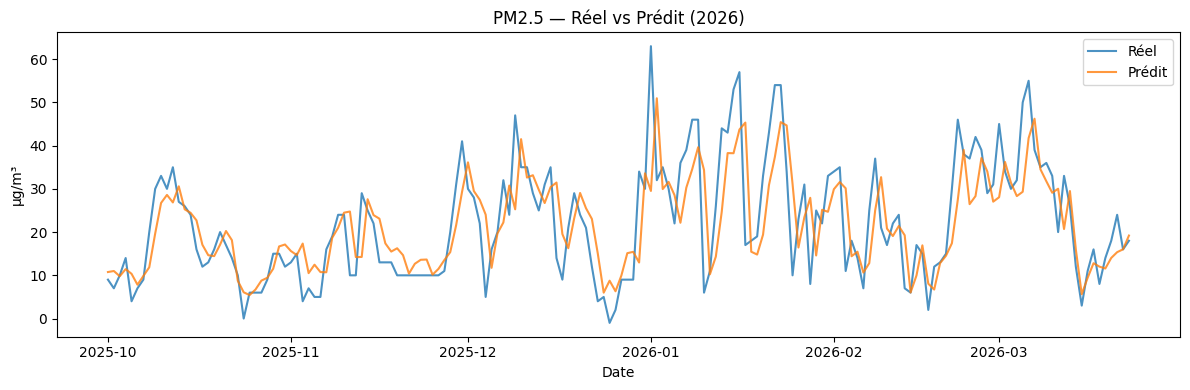

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(test["date"], y_test.values,  label="Réel",   alpha=0.8)
plt.plot(test["date"], y_pred,          label="Prédit", alpha=0.8)
plt.legend()
plt.title("PM2.5 — Réel vs Prédit (2026)")
plt.xlabel("Date")
plt.ylabel("µg/m³")
plt.tight_layout()
plt.show()

In [16]:
# saving the model to be used as a tool for an AI agent
import joblib
global_df.to_csv("global_dataset.csv", index=False)
joblib.dump(reg, "pm25_model.pkl")

['pm25_model.pkl']